In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_parquet("data/prepared_data.parquet")

In [38]:
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,logIC50,logCC50,logSI
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,...,0,0,0,0,0,3,0,1.979535,5.173221,3.371597
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,...,0,0,0,0,0,3,0,0.572014,1.856738,2.079442
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,...,0,0,0,0,0,3,0,5.415250,5.088474,0.542324
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,...,0,0,0,0,0,4,0,0.995333,4.690023,4.162553
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,...,0,0,0,0,0,0,0,4.683348,4.943576,0.832909


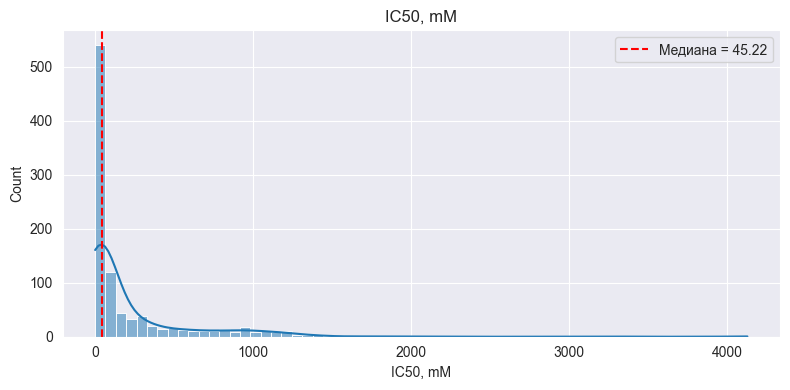

In [39]:
# Посмотрим на медиану и выбросы. В ходе экспериментов выяснено, что удаление выбросов ухудшает модель (хоть и незначительно), поэтому с выбросами ничего делать не будем

plt.figure(figsize=(8, 4))
sns.histplot(df['IC50, mM'], kde=True)
median_value = df['IC50, mM'].median()
plt.axvline(median_value, color='red', linestyle='--', label=f'Медиана = {median_value:.2f}')
plt.title('IC50, mM')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# Удалим целевые признаки для разделения выборок
targets = ['IC50, mM', 'CC50, mM', 'SI', 'logIC50', 'logCC50', 'logSI']
X = df.drop(columns=targets)

# Целевой признак
y_ic50 = df['IC50, mM']

median_ic50 = y_ic50.median()
y_ic50_class = (y_ic50 > median_ic50).astype(int)

X_train, X_test, y_train_iс50_class, y_test_iс50_class  = train_test_split(X, y_ic50_class, test_size=0.2, random_state=42)

In [41]:
# Масштабируем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# Функция для обучения и оценки классификатора
def evaluate_classifier(X_train, X_test, y_train, y_test, models_dict):
    results = []
    for name, (model, params) in models_dict.items():
        grid = GridSearchCV(model, params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]
        results.append({
            'model': name,
            'best_params': grid.best_params_,
            'f1': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_proba),
            'recall': recall_score(y_test, y_pred, average='binary'),
            'precision': precision_score(y_test, y_pred, average='binary')
        })
    return pd.DataFrame(results)

In [43]:
# Выбор моделей и гиперпараметров
class_models = {
    'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=42), {'C': [0.01, 0.1, 1, 10]}),
    'RandomForest': (RandomForestClassifier(random_state=42), {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}),
    'GradientBoosting': (GradientBoostingClassifier(random_state=42), {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]}),
    'XGBoost': (XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'), {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 6]})
}

In [44]:
# Обучаем несколько моделей. В данном случае лучшие результаты у RandomForest 
results_ic50_class = evaluate_classifier(X_train_scaled, X_test_scaled, y_train_iс50_class, y_test_iс50_class, class_models)
results_ic50_class

,model,best_params,f1,roc_auc,recall,precision
0,LogisticRegression,{'C': 0.1},0.682081,0.785967,0.670455,0.694118
1,RandomForest,"{'max_depth': 10, 'n_estimators': 200}",0.724138,0.824882,0.715909,0.732558
2,GradientBoosting,"{'learning_rate': 0.05, 'n_estimators': 100}",0.670391,0.813947,0.681818,0.659341
3,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.666667,0.812339,0.647727,0.686747
